# circRNA BSJ Peptide Analysis

Identify circRNA back-splice junction (BSJ)-derived peptides in the immunopeptidome by string matching detected IP peptides against pre-computed BSJ candidate sequences. Both canonical (5'→3') and reverse (3'→5') translation are considered.

**Data:**
- `all_candidate_bsj_peptides.fasta` — 8–11mer peptide windows centred on BSJs (forward + backward ORFs)
- `forward/backward_bsj_spanning_proteins.fasta` — full-length BSJ-spanning ORF proteins
- `forward_rolling_circle_proteins.fasta` — ORFs with no in-frame stop codon (ribosome traverses circle multiple times)
- `combined_peptide.tsv` — FragPipe DDA immunopeptidomics output (17 samples)

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import re
from collections import defaultdict

sns.set_style('white')

# --- Paths ---
BASE     = Path('/Users/vivianschu/repos/immunopeptidomics/circrna')
CIRC_DIR = BASE / 'data' / 'circ'
IP_DIR   = BASE / 'data' / 'ip'
FIG_DIR  = BASE / 'analysis' / 'figures'
FIG_DIR.mkdir(exist_ok=True)

# --- Global figure style ---
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
})

# --- Colour palette ---
PALETTE = {
    'forward':        "#4274C4",
    'backward':       "#9AB9EE",
    'rolling_circle': '#55A868',
    'MS/MS':          '#2d6a4f',
    'MBR':            '#95d5b2',
}
CAT_PALETTE = {
    'prostate cancer cells': '#4C72B0',
    'prostate cancer':       '#8AB6D6',
    'lung cancer cells':     '#DD8452',
    'organoid':              '#55A868',
    'PDX':                   '#C44E52',
}
CAT_ORDER = ['prostate cancer cells', 'prostate cancer',
             'lung cancer cells', 'organoid', 'PDX']

def save_fig(fig, name):
    # for ext in ('png'):
    fig.savefig(FIG_DIR / f'{name}.png', dpi=600, bbox_inches='tight')
    print(f'Saved: {name}')

## 1. Load circRNA Data

In [98]:
def parse_fasta(path):
    """Parse a FASTA file. Returns dict {header: sequence}."""
    records = {}
    with open(path) as fh:
        header, seq = None, []
        for line in fh:
            line = line.strip()
            if line.startswith('>'):
                if header is not None:
                    records[header] = ''.join(seq)
                header = line[1:]
                seq = []
            else:
                seq.append(line)
        if header is not None:
            records[header] = ''.join(seq)
    return records


CIRC_RE = re.compile(r'(circ_\d+)_(ORF\d+)_(forward|backward)_pos(\d+)_(\d+)mer')
PROT_RE = re.compile(r'(circ_\d+)_(ORF\d+)_(forward|backward)')
KV_RE   = re.compile(r'(\w+)=(\S+)')


def parse_candidate_header(header):
    """Parse BSJ candidate peptide FASTA header.
    Format: circ_{id}_{orf}_{dir}_pos{N}_{L}mer bsj_at={Z}
    """
    parts = header.split()
    m = CIRC_RE.match(parts[0])
    if not m:
        return None
    bsj_at = int(parts[1].split('=')[1]) if len(parts) > 1 else None
    return {
        'circ_id':   m.group(1),
        'orf_id':    m.group(2),
        'direction': m.group(3),
        'pos':       int(m.group(4)),
        'length':    int(m.group(5)),
        'bsj_at':    bsj_at,
    }


def parse_protein_header(header):
    """Parse BSJ / rolling-circle protein FASTA header."""
    m = PROT_RE.match(header)
    if not m:
        return None
    info = {
        'circ_id':   m.group(1),
        'orf_id':    m.group(2),
        'direction': m.group(3),
    }
    for k, v in KV_RE.findall(header):
        if k == 'len':
            info['len_aa'] = int(v.replace('aa', ''))
        elif k == 'circ_len':
            info['circ_len'] = int(v)
        elif k == 'frame':
            info['frame'] = int(v)
        elif k == 'bsj_aa':
            info['bsj_aa'] = int(v)
        elif k == 'category':
            info['category'] = v
        elif k == 'rolling_circle':
            info['rolling_circle'] = (v == 'True')
    return info

In [99]:
# --- Load candidate BSJ peptides ---
print('Parsing candidate BSJ peptides...')
candidate_fasta = parse_fasta(CIRC_DIR / 'all_candidate_bsj_peptides.fasta')
print(f'  FASTA entries: {len(candidate_fasta):,}')

candidate_records = []
seq_to_metas = defaultdict(list)

for header, seq in candidate_fasta.items():
    meta = parse_candidate_header(header)
    if meta:
        seq_uc = seq.upper()
        meta['sequence'] = seq_uc
        candidate_records.append(meta)
        seq_to_metas[seq_uc].append(meta)

candidates_df = pd.DataFrame(candidate_records)
print(f'  Parsed records:   {len(candidates_df):,}')
print(f'  Unique sequences: {candidates_df["sequence"].nunique():,}')
print()
print(candidates_df.groupby(['direction', 'length']).size().unstack('length'))

Parsing candidate BSJ peptides...
  FASTA entries: 347,950
  Parsed records:   347,950
  Unique sequences: 347,950

length        8      9      10     11
direction                            
backward   23526  27312  30775  33943
forward    47486  54937  61835  68136


In [100]:
# --- Load protein FASTAs for background statistics ---
print('Parsing protein FASTAs...')
fwd_fasta  = parse_fasta(CIRC_DIR / 'forward_bsj_spanning_proteins.fasta')
bwd_fasta  = parse_fasta(CIRC_DIR / 'backward_bsj_spanning_proteins.fasta')
roll_fasta = parse_fasta(CIRC_DIR / 'forward_rolling_circle_proteins.fasta')

fwd_prot_df  = pd.DataFrame([x for x in (parse_protein_header(h) for h in fwd_fasta)  if x])
bwd_prot_df  = pd.DataFrame([x for x in (parse_protein_header(h) for h in bwd_fasta)  if x])
roll_prot_df = pd.DataFrame([x for x in (parse_protein_header(h) for h in roll_fasta) if x])

fwd_prot_df['source']  = 'forward_BSJ'
bwd_prot_df['source']  = 'backward_BSJ'
roll_prot_df['source'] = 'rolling_circle'
all_prots_df = pd.concat([fwd_prot_df, bwd_prot_df, roll_prot_df], ignore_index=True)

print(f'Forward BSJ proteins:  {len(fwd_prot_df):>6,}   (unique circRNAs: {fwd_prot_df["circ_id"].nunique():,})')
print(f'Backward BSJ proteins: {len(bwd_prot_df):>6,}   (unique circRNAs: {bwd_prot_df["circ_id"].nunique():,})')
print(f'Rolling circle:        {len(roll_prot_df):>6,}   (unique circRNAs: {roll_prot_df["circ_id"].nunique():,})')

Parsing protein FASTAs...
Forward BSJ proteins:  14,178   (unique circRNAs: 7,969)
Backward BSJ proteins:  7,321   (unique circRNAs: 5,210)
Rolling circle:         7,731   (unique circRNAs: 5,760)


## 2. Load IP Immunopeptidomics Data

In [101]:
# --- Sample metadata ---
metadata = pd.read_csv('/Volumes/Extreme SSD/IP/metadata.csv')
metadata['Sample Name'] = metadata['Sample Name'].str.replace('XDO', 'XD0')

# Map combined_peptide column prefixes -> metadata sample names
COL_TO_META = {
    'A549_1':      'A549',
    'Ahmed_1':     'Ahmed1',
    'Ahmed_2':     'Ahmed2',
    'Ahmed_3':     'Ahmed3',
    'DU145_1':     'DU145',
    'H2286_1':     'H2286',
    'H446_1':      'H446',
    'H526_1':      'H526',
    'H69_1':       'H69',
    'LX108_1':     'LX108',
    'LX22_1':      'LX22',
    'PC3_100M_1':  'PC3_100M',
    'PC3_1M_1':    'PC3_1M',
    'PHLC239_1':   'PHLC239',
    'PHLC4375_1':  'PHLC4375',
    'V16A_1':      'V16A',
    'XD04375_1':   'XD04375',
}

print(metadata[['Sample Name', 'category', 'ifny']].to_string(index=False))

Sample Name              category ifny
     PC3_1M prostate cancer cells    *
   PC3_100M prostate cancer cells    *
      DU145 prostate cancer cells    *
       V16A prostate cancer cells    *
     Ahmed1       prostate cancer  NaN
     Ahmed2       prostate cancer  NaN
     Ahmed3       prostate cancer  NaN
       A549     lung cancer cells    *
        H69     lung cancer cells    *
       H446     lung cancer cells    *
       H526     lung cancer cells    *
      H2286     lung cancer cells    *
    XD04375              organoid    *
       LX22              organoid   **
      LX108              organoid  NaN
   PHLC4375                   PDX  NaN
    PHLC239                   PDX  NaN


In [102]:
# --- Load combined_peptide.tsv ---
print('Loading IP peptide table...')
ip_df = pd.read_csv(IP_DIR / 'combined_peptide.tsv', sep='\t')
print(f'  Rows: {len(ip_df):,}')
print(f'  Unique peptide sequences: {ip_df["Peptide Sequence"].nunique():,}')

match_cols       = [c for c in ip_df.columns if c.endswith('Match Type')]
sample_col_names = [c.replace(' Match Type', '') for c in match_cols]

# Per-sample detection counts
sample_stats = []
for sc in sample_col_names:
    mt      = ip_df[f'{sc} Match Type']
    n_msms  = (mt == 'MS/MS').sum()
    n_mbr   = (mt == 'MBR').sum()
    meta_name = COL_TO_META.get(sc, sc)
    cat_vals  = metadata.loc[metadata['Sample Name'] == meta_name, 'category']
    cat = cat_vals.iloc[0] if len(cat_vals) > 0 else 'unknown'
    sample_stats.append({
        'sample_col': sc,
        'sample':     meta_name,
        'category':   cat,
        'n_msms':     n_msms,
        'n_mbr':      n_mbr,
        'n_total':    n_msms + n_mbr,
    })

sample_stats_df = pd.DataFrame(sample_stats)
sample_stats_df['cat_order'] = sample_stats_df['category'].map(
    {c: i for i, c in enumerate(CAT_ORDER)}
)
sample_stats_df = sample_stats_df.sort_values(['cat_order', 'sample']).reset_index(drop=True)
print()
print(sample_stats_df[['sample', 'category', 'n_msms', 'n_mbr', 'n_total']].to_string(index=False))

Loading IP peptide table...
  Rows: 47,249
  Unique peptide sequences: 47,249

  sample              category  n_msms  n_mbr  n_total
   DU145 prostate cancer cells    6197   2230     8427
PC3_100M prostate cancer cells   11144     92    11236
  PC3_1M prostate cancer cells    6252    601     6853
    V16A prostate cancer cells    3176   2056     5232
  Ahmed1       prostate cancer    5276   2046     7322
  Ahmed2       prostate cancer    4779   1209     5988
  Ahmed3       prostate cancer    5199   1591     6790
    A549     lung cancer cells    3297   2069     5366
   H2286     lung cancer cells    7094    203     7297
    H446     lung cancer cells    1410   1104     2514
    H526     lung cancer cells    3760    182     3942
     H69     lung cancer cells    5175   1201     6376
   LX108              organoid    6870     57     6927
    LX22              organoid    8300     95     8395
 XD04375              organoid    2976   1722     4698
 PHLC239                   PDX    1121   

## 3. String Matching: IP Peptides vs. BSJ Candidates

In [103]:
import math

# ── Helpers ──────────────────────────────────────────────────────────────────

def seq_entropy(seq):
    """Shannon entropy of amino-acid composition (higher = more complex)."""
    n = len(seq)
    return -sum((seq.count(aa)/n) * math.log2(seq.count(aa)/n)
                for aa in set(seq))

def is_low_complexity(seq, min_distinct_aa=4, min_entropy=1.0):
    """True if the sequence looks like a repetitive/low-complexity run."""
    return len(set(seq)) < min_distinct_aa or seq_entropy(seq) < min_entropy

def canonical_proteins(seq, df):
    """Return canonical UniProt protein IDs for a given peptide sequence."""
    rows = df[df['Peptide Sequence'].str.upper() == seq]
    return [p for p in rows['Protein'].dropna()
            if str(p).startswith(('sp|', 'tr|'))]

def msms_samples(seq, df, sample_cols):
    """Return list of samples in which a peptide was MS/MS-confirmed."""
    rows = df[df['Peptide Sequence'].str.upper() == seq]
    return [sc for sc in sample_cols
            if (rows[f'{sc} Match Type'] == 'MS/MS').any()]

# ── Build candidate and IP sets ───────────────────────────────────────────────

ip_seqs   = set(ip_df['Peptide Sequence'].dropna().str.upper())
cand_seqs = set(candidates_df['sequence'])   # already uppercase

raw_hits = ip_seqs & cand_seqs

# ── Apply filters ─────────────────────────────────────────────────────────────

# Filter 1: MS/MS confirmed in at least one sample
msms_mask = pd.Series(False, index=ip_df.index)
for sc in sample_col_names:
    msms_mask |= (ip_df[f'{sc} Match Type'] == 'MS/MS')
ip_seqs_msms = set(ip_df.loc[msms_mask, 'Peptide Sequence'].dropna().str.upper())

hits_msms = raw_hits & ip_seqs_msms

# Filter 2: Remove low-complexity sequences
hits_complex = {s for s in hits_msms if not is_low_complexity(s)}

# Filter 3: BSJ junction depth — require >= 2 residues from each side of the BSJ
#   bsj_at = position of BSJ (1-indexed from N-term)
#   need: bsj_at >= 2  AND  (length - bsj_at) >= 2
MIN_BSJ_DEPTH = 2

def has_sufficient_bsj_depth(seq, min_depth=MIN_BSJ_DEPTH):
    metas = seq_to_metas.get(seq, [])
    return any(
        m['bsj_at'] is not None
        and m['bsj_at'] >= min_depth
        and (m['length'] - m['bsj_at']) >= min_depth
        for m in metas
    )

hits_bsj = {s for s in hits_complex if has_sufficient_bsj_depth(s)}

# ── Annotate each hit ─────────────────────────────────────────────────────────

rows = []
for seq in sorted(raw_hits):
    canon = canonical_proteins(seq, ip_df)
    msms  = msms_samples(seq, ip_df, sample_col_names)
    metas = seq_to_metas.get(seq, [])
    directions = list({m['direction'] for m in metas})
    bsj_positions = [m['bsj_at'] for m in metas if m['bsj_at'] is not None]
    rows.append({
        'sequence':          seq,
        'length':            len(seq),
        'low_complexity':    is_low_complexity(seq),
        'n_distinct_aa':     len(set(seq)),
        'entropy':           round(seq_entropy(seq), 2),
        'msms_confirmed':    bool(msms),
        'msms_samples':      msms,
        'canonical_proteins': canon,
        'in_canonical_db':   bool(canon),
        'directions':        directions,
        'bsj_positions':     bsj_positions,
        'sufficient_bsj':    has_sufficient_bsj_depth(seq),
    })

hits_df = pd.DataFrame(rows)

# ── Summary ───────────────────────────────────────────────────────────────────

print('=' * 65)
print(f'  IP peptide sequences (unique):        {len(ip_seqs):>10,}')
print(f'  BSJ candidate sequences (unique):     {len(cand_seqs):>10,}')
print()
print(f'  Raw hits  (IP ∩ BSJ):                 {len(raw_hits):>10,}')
print(f'    → after MS/MS filter:               {len(hits_msms):>10,}')
print(f'    → after low-complexity filter:      {len(hits_complex):>10,}')
print(f'    → after BSJ junction depth filter:  {len(hits_bsj):>10,}')
print()
print(f'  Hits mapping to canonical proteins:   {hits_df["in_canonical_db"].sum():>10,}')
print(f'  (NOTE: all hits are ambiguous — combined_peptide.tsv was searched')
print(f'   against canonical proteins only; circRNA-unique peptides require')
print(f'   re-searching raw spectra against the circRNA FASTA databases.)')
print('=' * 65)
print()
print('Per-hit annotation:')
display_cols = ['sequence', 'length', 'low_complexity', 'n_distinct_aa',
                'entropy', 'msms_confirmed', 'in_canonical_db',
                'directions', 'sufficient_bsj']
print(hits_df[display_cols].to_string(index=False))

# ── Set final hit variables for downstream figures ────────────────────────────

# Use the fully-filtered set as "confident hits"
# (likely still false-positives without raw-spectra re-search, but most stringent)
confident_hits = hits_bsj

if confident_hits:
    hit_ip_df = ip_df[ip_df['Peptide Sequence'].str.upper().isin(confident_hits)].copy()
    hit_cand_records = []
    for seq in confident_hits:
        hit_cand_records.extend(seq_to_metas[seq])
    hit_cand_df = pd.DataFrame(hit_cand_records)
else:
    hit_ip_df   = pd.DataFrame()
    hit_cand_df = pd.DataFrame()
    print('\nNo confident circRNA BSJ-derived peptides after filtering.')

  IP peptide sequences (unique):            47,249
  BSJ candidate sequences (unique):        347,950

  Raw hits  (IP ∩ BSJ):                          5
    → after MS/MS filter:                        5
    → after low-complexity filter:               1
    → after BSJ junction depth filter:           1

  Hits mapping to canonical proteins:            5
  (NOTE: all hits are ambiguous — combined_peptide.tsv was searched
   against canonical proteins only; circRNA-unique peptides require
   re-searching raw spectra against the circRNA FASTA databases.)

Per-hit annotation:
   sequence  length  low_complexity  n_distinct_aa  entropy  msms_confirmed  in_canonical_db directions  sufficient_bsj
   LLLLLLLL       8            True              1    -0.00            True             True [backward]            True
  LLLLLLLLL       9            True              1    -0.00            True             True [backward]            True
 LLLLLLLLLL      10            True              1    -0.0

## 4. Figures

Saved: candidate_library


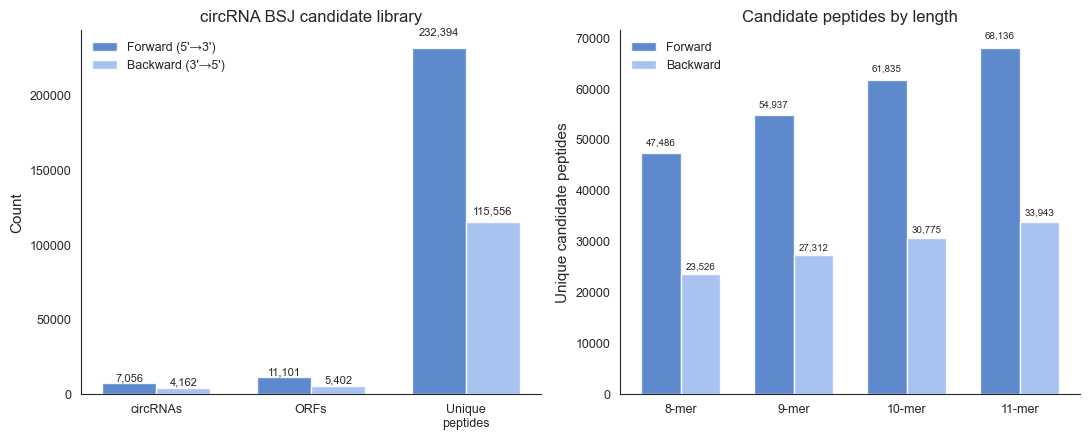

In [104]:
# --- Fig 1: circRNA BSJ candidate library overview ---
circs_fwd = candidates_df.loc[candidates_df['direction']=='forward', 'circ_id'].nunique()
circs_bwd = candidates_df.loc[candidates_df['direction']=='backward', 'circ_id'].nunique()
orfs_fwd  = candidates_df.loc[candidates_df['direction']=='forward',  ['circ_id','orf_id']].drop_duplicates().shape[0]
orfs_bwd  = candidates_df.loc[candidates_df['direction']=='backward', ['circ_id','orf_id']].drop_duplicates().shape[0]
peps_fwd  = candidates_df.loc[candidates_df['direction']=='forward',  'sequence'].nunique()
peps_bwd  = candidates_df.loc[candidates_df['direction']=='backward', 'sequence'].nunique()

length_pivot = (
    candidates_df
    .groupby(['direction', 'length'])['sequence']
    .nunique()
    .reset_index(name='count')
    .pivot(index='length', columns='direction', values='count')
    .fillna(0).astype(int)
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Panel A — entity counts per direction
levels   = ['circRNAs', 'ORFs', 'Unique\npeptides']
fwd_vals = [circs_fwd, orfs_fwd, peps_fwd]
bwd_vals = [circs_bwd, orfs_bwd, peps_bwd]
x = np.arange(len(levels))
w = 0.35
bars_f = axes[0].bar(x - w/2, fwd_vals, w, label="Forward (5'\u21923')",
                     color=PALETTE['forward'],  alpha=0.85)
bars_b = axes[0].bar(x + w/2, bwd_vals, w, label="Backward (3'\u21925')",
                     color=PALETTE['backward'], alpha=0.85)
for bar in list(bars_f) + list(bars_b):
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h * 1.03,
                 f'{h:,}', ha='center', va='bottom', fontsize=8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(levels)
axes[0].set_ylabel('Count')
axes[0].set_title('circRNA BSJ candidate library')
axes[0].legend(frameon=False)
sns.despine(ax=axes[0])

# Panel B — candidate peptides by mer length
fwd_len = length_pivot['forward']  if 'forward'  in length_pivot.columns else pd.Series(0, index=length_pivot.index)
bwd_len = length_pivot['backward'] if 'backward' in length_pivot.columns else pd.Series(0, index=length_pivot.index)
x2 = np.arange(len(length_pivot))
bars_f2 = axes[1].bar(x2 - w/2, fwd_len, w, label='Forward',
                      color=PALETTE['forward'],  alpha=0.85)
bars_b2 = axes[1].bar(x2 + w/2, bwd_len, w, label='Backward',
                      color=PALETTE['backward'], alpha=0.85)
for bar in list(bars_f2) + list(bars_b2):
    h = bar.get_height()
    if h > 0:
        axes[1].text(bar.get_x() + bar.get_width()/2, h * 1.02,
                     f'{int(h):,}', ha='center', va='bottom', fontsize=7)
axes[1].set_xticks(x2)
axes[1].set_xticklabels([f'{int(l)}-mer' for l in length_pivot.index])
axes[1].set_ylabel('Unique candidate peptides')
axes[1].set_title('Candidate peptides by length')
axes[1].legend(frameon=False)
sns.despine(ax=axes[1])

plt.tight_layout()
save_fig(fig, 'candidate_library')
plt.show()

Saved: ip_overview


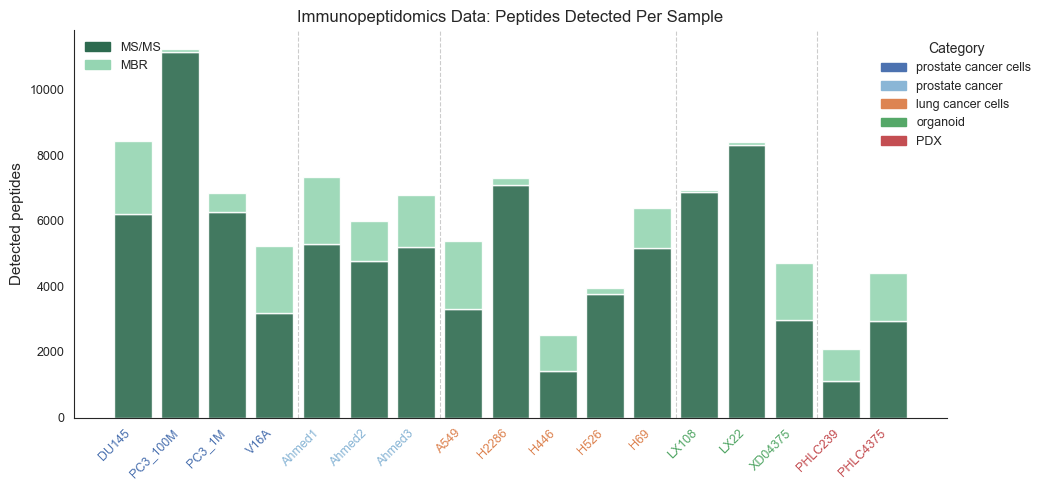

In [105]:
# --- Fig 2: IP immunopeptidome overview ---
fig, ax = plt.subplots(figsize=(10.5, 5))

x = np.arange(len(sample_stats_df))
ax.bar(x, sample_stats_df['n_msms'],
       color=PALETTE['MS/MS'], label='MS/MS', alpha=0.9)
ax.bar(x, sample_stats_df['n_mbr'],
       bottom=sample_stats_df['n_msms'],
       color=PALETTE['MBR'],   label='MBR',   alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(sample_stats_df['sample'], rotation=45, ha='right')
for tick, row in zip(ax.get_xticklabels(), sample_stats_df.itertuples()):
    tick.set_color(CAT_PALETTE.get(row.category, 'black'))

# Vertical separators between categories
prev_cat = None
for i, row in enumerate(sample_stats_df.itertuples()):
    if row.category != prev_cat and i > 0:
        ax.axvline(i - 0.5, color='grey', lw=0.8, ls='--', alpha=0.4)
    prev_cat = row.category

# Two legends: detection type + category
det_patches = [
    mpatches.Patch(color=PALETTE['MS/MS'], label='MS/MS'),
    mpatches.Patch(color=PALETTE['MBR'],   label='MBR'),
]
cat_patches = [
    mpatches.Patch(color=CAT_PALETTE.get(c, 'grey'), label=c)
    for c in CAT_ORDER if c in sample_stats_df['category'].values
]
leg1 = ax.legend(handles=det_patches, frameon=False, loc='upper left')
ax.add_artist(leg1)
ax.legend(handles=cat_patches, frameon=False, loc='upper right',title='Category', bbox_to_anchor=(1.11, 1.0))

ax.set_ylabel('Detected peptides')
ax.set_title('Immunopeptidomics Data: Peptides Detected Per Sample')
sns.despine(ax=ax)
plt.tight_layout()
save_fig(fig, 'ip_overview')
plt.show()

Saved: ip_length_distribution


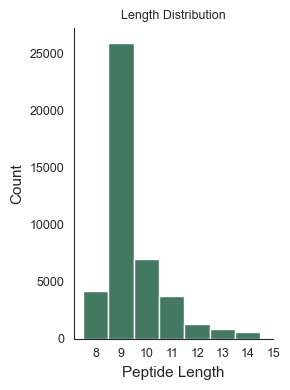

In [106]:
# Plot length distribution of ip_seqs
fig, ax = plt.subplots(figsize=(3, 4))
ip_df['Peptide Length'] = ip_df['Peptide Sequence'].str.len()
sns.histplot(ip_df['Peptide Length'], bins=np.arange(7.5, 15.5, 1), ax=ax, color=PALETTE['MS/MS'], alpha=0.9)
ax.set_xticks(range(8, 16))
ax.set_xticklabels([f'{i}' for i in range(8, 16)])
ax.set_xlabel('Peptide Length')
ax.set_ylabel('Count')
ax.set_title('Length Distribution', fontsize=9)
sns.despine(ax=ax)
plt.tight_layout()
save_fig(fig, 'ip_length_distribution')
plt.show()

ValueError: 'transform' is not allowed as a keyword argument; axhline generates its own transform.

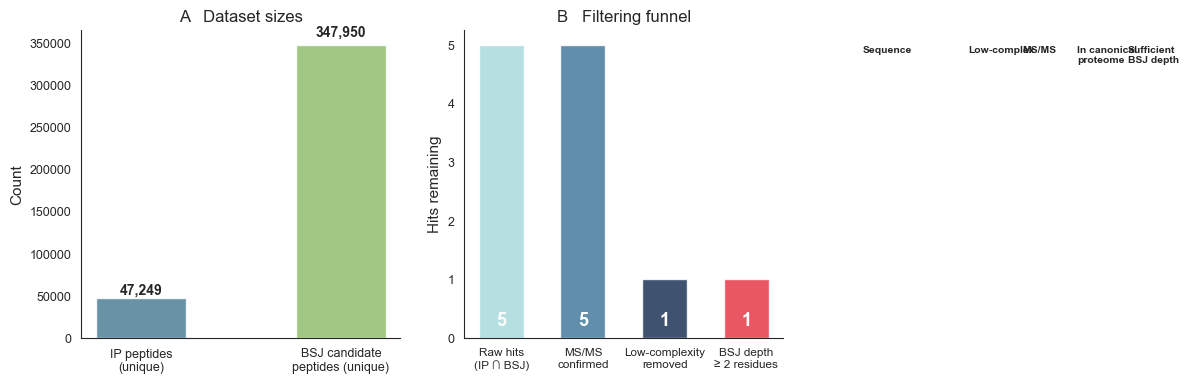

In [107]:
# --- Fig 3: String-matching results and filtering funnel ---
total_ip   = len(ip_seqs)
total_cand = len(cand_seqs)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Panel A — dataset sizes
labels_a = ['IP peptides\n(unique)', 'BSJ candidate\npeptides (unique)']
values_a = [total_ip, total_cand]
colors_a = ['#4e8098', '#90be6d']
bars_a = axes[0].bar(labels_a, values_a, color=colors_a, alpha=0.85, width=0.45)
for bar, val in zip(bars_a, values_a):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                 f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_title('A   Dataset sizes')
sns.despine(ax=axes[0])

# Panel B — filtering funnel
funnel_labels = [
    'Raw hits\n(IP ∩ BSJ)',
    'MS/MS\nconfirmed',
    'Low-complexity\nremoved',
    'BSJ depth\n≥ 2 residues',
]
funnel_values = [len(raw_hits), len(hits_msms), len(hits_complex), len(hits_bsj)]
funnel_colors = ['#a8dadc', '#457b9d', '#1d3557', '#e63946']
bars_b = axes[1].bar(range(len(funnel_labels)), funnel_values,
                     color=funnel_colors, alpha=0.85, width=0.55)
for bar, val in zip(bars_b, funnel_values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 max(funnel_values) * 0.03,
                 str(val), ha='center', va='bottom', fontsize=13, fontweight='bold',
                 color='white')
axes[1].set_xticks(range(len(funnel_labels)))
axes[1].set_xticklabels(funnel_labels, fontsize=8.5)
axes[1].set_ylabel('Hits remaining')
axes[1].set_title('B   Filtering funnel')
sns.despine(ax=axes[1])

# Panel C — hit annotation table (all raw hits)
if not hits_df.empty:
    col_x = [0.05, 0.38, 0.55, 0.72, 0.88]
    col_headers = ['Sequence', 'Low-complex', 'MS/MS', 'In canonical\nproteome', 'Sufficient\nBSJ depth']
    axes[2].axis('off')
    for cx, hdr in zip(col_x, col_headers):
        axes[2].text(cx, 0.95, hdr, ha='left', va='top', fontsize=7.5,
                     fontweight='bold', transform=axes[2].transAxes)
    axes[2].axhline(y=0.90, xmin=0, xmax=1, color='grey', lw=0.8,
                    transform=axes[2].transAxes)
    row_y = np.linspace(0.83, 0.05, len(hits_df))
    bool_sym = {True: '✓', False: '✗'}
    bool_col = {True: '#c44e52', False: '#2d6a4f'}
    for y, (_, row) in zip(row_y, hits_df.iterrows()):
        axes[2].text(col_x[0], y, row['sequence'], ha='left', va='center',
                     fontsize=7, fontfamily='monospace', transform=axes[2].transAxes)
        for ci, (col, val) in enumerate(zip(
            ['low_complexity', 'msms_confirmed', 'in_canonical_db', 'sufficient_bsj'],
            [row['low_complexity'], row['msms_confirmed'],
             row['in_canonical_db'], row['sufficient_bsj']]
        )):
            sym = bool_sym[val]
            clr = bool_col[val] if col in ('low_complexity', 'in_canonical_db') else bool_col[not val]
            axes[2].text(col_x[ci+1] + 0.05, y, sym, ha='center', va='center',
                         fontsize=9, color=clr, transform=axes[2].transAxes)
    axes[2].set_title('C   Raw hit annotation', fontsize=12)
else:
    axes[2].text(0.5, 0.5, 'No raw hits', ha='center', va='center',
                 transform=axes[2].transAxes, fontsize=12, color='grey')
    axes[2].axis('off')
    axes[2].set_title('C   Raw hit annotation', fontsize=12)

plt.tight_layout()
save_fig(fig, 'fig3_string_matching')
plt.show()

Saved: fig4_hit_characterisation


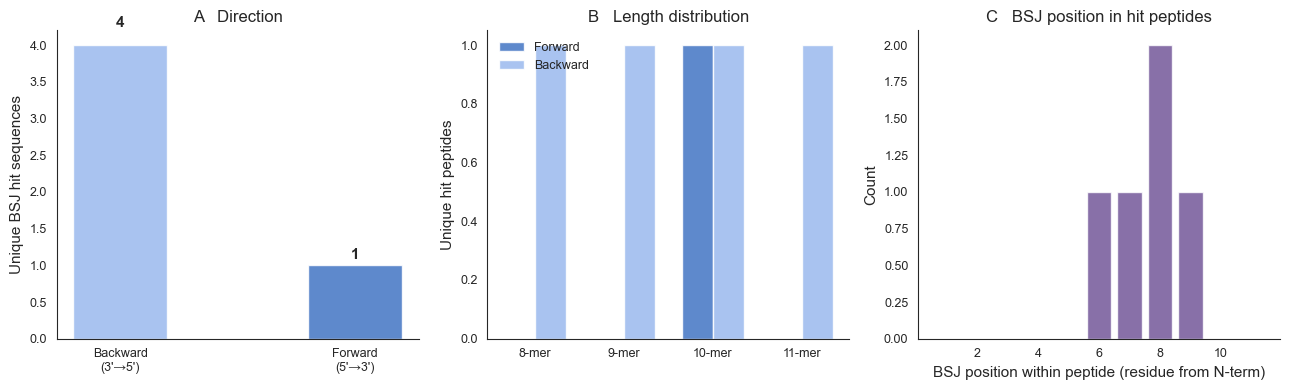

In [ ]:
# --- Fig 4: Hit characterisation (rendered only when hits are found) ---
if hit_ip_df.empty:
    print('No hits — Fig 4 skipped.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))

    # A — forward vs backward
    dir_counts = hit_cand_df.groupby('direction')['sequence'].nunique()
    dir_labels = {'forward': "Forward\n(5'\u21923')", 'backward': "Backward\n(3'\u21925')"}
    colors_dir = [PALETTE.get(d, 'grey') for d in dir_counts.index]
    axes[0].bar([dir_labels.get(d, d) for d in dir_counts.index],
                dir_counts.values, color=colors_dir, alpha=0.85, width=0.4)
    for i, v in enumerate(dir_counts.values):
        axes[0].text(i, v * 1.05, str(v), ha='center', va='bottom',
                     fontsize=11, fontweight='bold')
    axes[0].set_ylabel('Unique BSJ hit sequences')
    axes[0].set_title('A   Direction')
    sns.despine(ax=axes[0])

    # B — length distribution of hits
    len_pivot = (
        hit_cand_df
        .groupby(['length', 'direction'])['sequence']
        .nunique()
        .reset_index(name='count')
        .pivot(index='length', columns='direction', values='count')
        .fillna(0).astype(int)
    )
    x_l = np.arange(len(len_pivot))
    w_l = 0.35
    for i, (d, col) in enumerate([
            ('forward', PALETTE['forward']), ('backward', PALETTE['backward'])
    ]):
        if d in len_pivot.columns:
            axes[1].bar(x_l + (i - 0.5) * w_l, len_pivot[d], w_l,
                        label=d.capitalize(), color=col, alpha=0.85)
    axes[1].set_xticks(x_l)
    axes[1].set_xticklabels([f'{int(l)}-mer' for l in len_pivot.index])
    axes[1].set_ylabel('Unique hit peptides')
    axes[1].set_title('B   Length distribution')
    axes[1].legend(frameon=False)
    sns.despine(ax=axes[1])

    # C — BSJ position within hit peptide
    axes[2].hist(hit_cand_df['bsj_at'].dropna().astype(int),
                 bins=range(1, 13), color='#6a4c93', alpha=0.8,
                 rwidth=0.8, align='left')
    axes[2].set_xlabel('BSJ position within peptide (residue from N-term)')
    axes[2].set_ylabel('Count')
    axes[2].set_title('C   BSJ position in hit peptides')
    sns.despine(ax=axes[2])

    plt.tight_layout()
    save_fig(fig, 'fig4_hit_characterisation')
    plt.show()

Saved: fig5_hits_per_sample


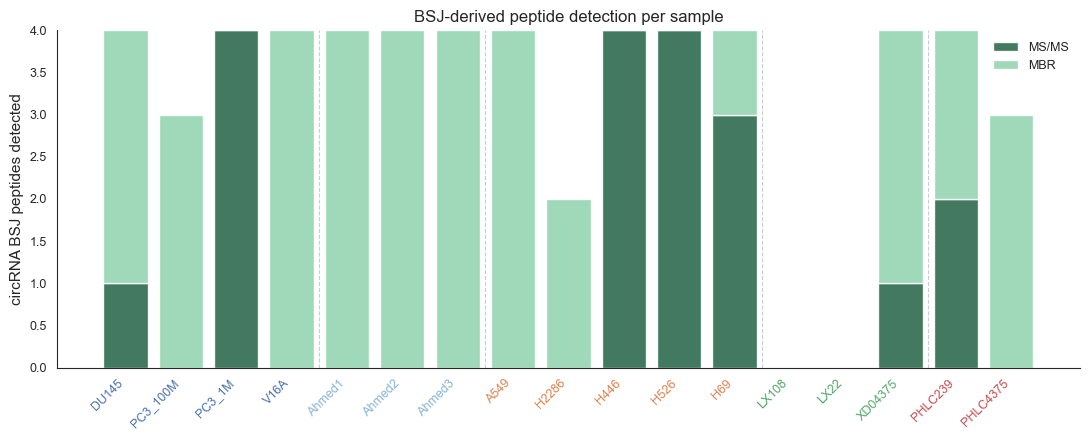

In [ ]:
# --- Fig 5: BSJ hit detection per sample ---
if hit_ip_df.empty:
    print('No hits — Fig 5 skipped.')
else:
    sample_hits = []
    for sc in sample_col_names:
        mt_col = f'{sc} Match Type'
        if mt_col not in hit_ip_df.columns:
            continue
        mt = hit_ip_df[mt_col]
        n_msms = (mt == 'MS/MS').sum()
        n_mbr  = (mt == 'MBR').sum()
        meta_name = COL_TO_META.get(sc, sc)
        cat_vals  = metadata.loc[metadata['Sample Name'] == meta_name, 'category']
        cat = cat_vals.iloc[0] if len(cat_vals) > 0 else 'unknown'
        sample_hits.append({
            'sample': meta_name, 'category': cat,
            'n_msms': n_msms,    'n_mbr': n_mbr,
        })

    sh_df = pd.DataFrame(sample_hits)
    sh_df['cat_order'] = sh_df['category'].map({c: i for i, c in enumerate(CAT_ORDER)})
    sh_df = sh_df.sort_values(['cat_order', 'sample']).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(11, 4.5))
    x = np.arange(len(sh_df))
    ax.bar(x, sh_df['n_msms'], color=PALETTE['MS/MS'], label='MS/MS', alpha=0.9)
    ax.bar(x, sh_df['n_mbr'],  bottom=sh_df['n_msms'],
           color=PALETTE['MBR'], label='MBR', alpha=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels(sh_df['sample'], rotation=45, ha='right')
    for tick, row in zip(ax.get_xticklabels(), sh_df.itertuples()):
        tick.set_color(CAT_PALETTE.get(row.category, 'black'))
    prev_cat = None
    for i, row in enumerate(sh_df.itertuples()):
        if row.category != prev_cat and i > 0:
            ax.axvline(i - 0.5, color='grey', lw=0.8, ls='--', alpha=0.4)
        prev_cat = row.category
    ax.set_ylabel('circRNA BSJ peptides detected')
    ax.set_title('BSJ-derived peptide detection per sample')
    ax.legend(frameon=False)
    sns.despine(ax=ax)
    plt.tight_layout()
    save_fig(fig, 'fig5_hits_per_sample')
    plt.show()

Saved: fig6_circrna_hits


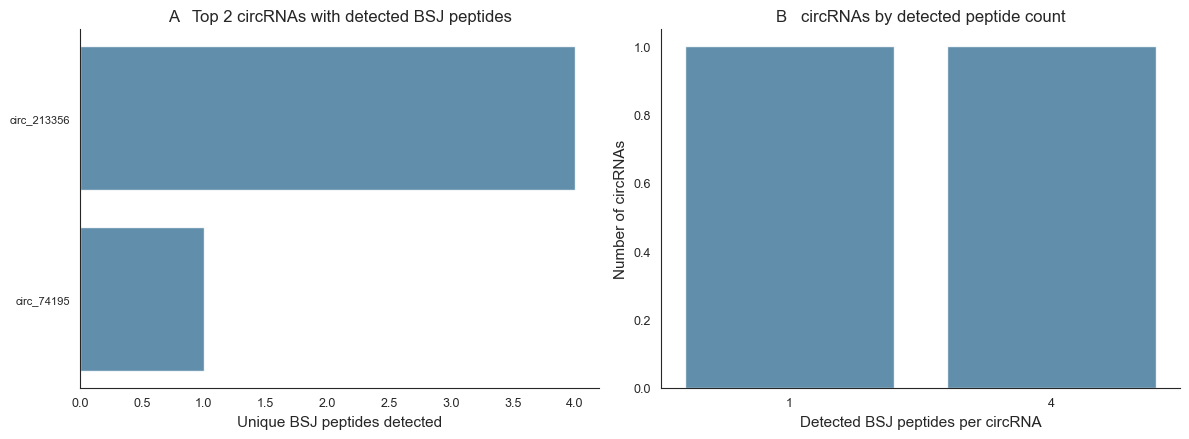

In [ ]:
# --- Fig 6: circRNA-level hit summary ---
if hit_cand_df.empty:
    print('No hits — Fig 6 skipped.')
else:
    circ_hit_counts = (
        hit_cand_df
        .groupby('circ_id')['sequence']
        .nunique()
        .sort_values(ascending=False)
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    # A — top circRNAs ranked by detected BSJ peptides
    top_n = min(20, len(circ_hit_counts))
    top   = circ_hit_counts.head(top_n)
    axes[0].barh(range(top_n), top.values, color='#457b9d', alpha=0.85)
    axes[0].set_yticks(range(top_n))
    axes[0].set_yticklabels(top.index, fontsize=8)
    axes[0].invert_yaxis()
    axes[0].set_xlabel('Unique BSJ peptides detected')
    axes[0].set_title(f'A   Top {top_n} circRNAs with detected BSJ peptides')
    sns.despine(ax=axes[0])

    # B — distribution across circRNAs
    dist = circ_hit_counts.value_counts().sort_index()
    axes[1].bar(dist.index.astype(str), dist.values, color='#457b9d', alpha=0.85)
    axes[1].set_xlabel('Detected BSJ peptides per circRNA')
    axes[1].set_ylabel('Number of circRNAs')
    axes[1].set_title('B   circRNAs by detected peptide count')
    sns.despine(ax=axes[1])

    plt.tight_layout()
    save_fig(fig, 'fig6_circrna_hits')
    plt.show()

Saved: fig7_orf_lengths


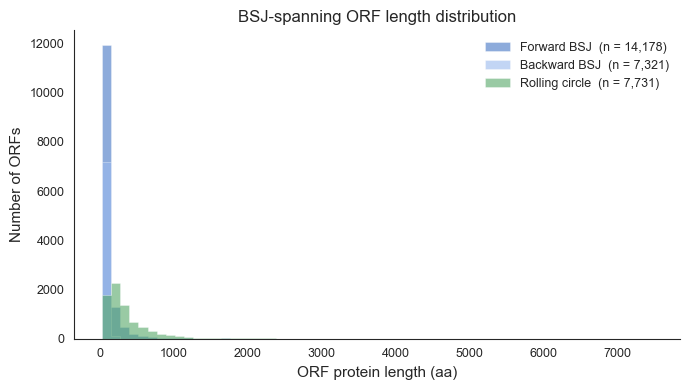

In [ ]:
# --- Fig 7: ORF protein length distributions ---
fig, ax = plt.subplots(figsize=(7, 4))

all_len = all_prots_df['len_aa'].dropna()
bins = np.histogram_bin_edges(all_len, bins=60)

for source, label, color in [
    ('forward_BSJ',    'Forward BSJ',    PALETTE['forward']),
    ('backward_BSJ',   'Backward BSJ',   PALETTE['backward']),
    ('rolling_circle', 'Rolling circle', PALETTE['rolling_circle']),
]:
    sub = all_prots_df.loc[all_prots_df['source'] == source, 'len_aa'].dropna()
    ax.hist(sub, bins=bins, alpha=0.6, color=color,
            label=f'{label}  (n = {len(sub):,})',
            histtype='stepfilled', edgecolor='white', linewidth=0.4)

ax.set_xlabel('ORF protein length (aa)')
ax.set_ylabel('Number of ORFs')
ax.set_title('BSJ-spanning ORF length distribution')
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.tight_layout()
save_fig(fig, 'fig7_orf_lengths')
plt.show()

Saved: fig8_circrna_length_vs_orfs


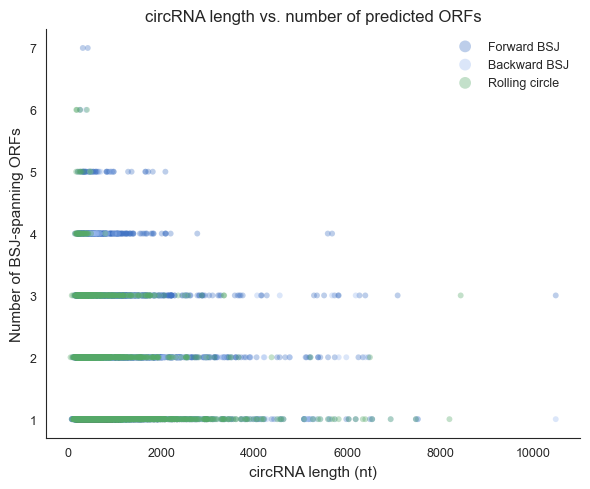

In [ ]:
# --- Fig 8: circRNA length vs. number of predicted ORFs ---
orfs_per_circ = (
    all_prots_df
    .groupby(['circ_id', 'source'])
    .agg(n_orfs=('orf_id', 'nunique'), circ_len=('circ_len', 'first'))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(6, 5))
for source, label, color in [
    ('forward_BSJ',    'Forward BSJ',    PALETTE['forward']),
    ('backward_BSJ',   'Backward BSJ',   PALETTE['backward']),
    ('rolling_circle', 'Rolling circle', PALETTE['rolling_circle']),
]:
    sub = orfs_per_circ[orfs_per_circ['source'] == source]
    ax.scatter(sub['circ_len'], sub['n_orfs'],
               alpha=0.35, s=18, color=color, label=label, edgecolors='none')

ax.set_xlabel('circRNA length (nt)')
ax.set_ylabel('Number of BSJ-spanning ORFs')
ax.set_title('circRNA length vs. number of predicted ORFs')
ax.legend(frameon=False, markerscale=2)
sns.despine(ax=ax)
plt.tight_layout()
save_fig(fig, 'fig8_circrna_length_vs_orfs')
plt.show()